In [7]:
import json
import pandas as pd 

In [8]:

loc = '../data/MIND.txt'

mapping = '../data/MIND_item_category_map.txt'
lines = []

with open(mapping, 'r') as f:
    lines = f.readlines()
mapping = pd.DataFrame([line.strip().split(' ') for line in lines],
                          columns=['article', 'categories'])


with open(loc, 'r') as f:
    lines = f.readlines()


df = [{'user_id': entry.split(' ')[0], 'history': [x.strip() for x in entry.split(" ")[1:]]} for entry in lines]
df = pd.DataFrame.from_records(df)

cat_dict = mapping.set_index('article')['categories'].to_dict()
cat_dict = {str(k): v for k, v in cat_dict.items()}
# 2) Map each history list to its categories
df['categories'] = df['history'].apply(lambda hist:
    [cat_dict.get(artist_id, None) for artist_id in hist]
)

df['unique_categories'] = df['categories'].apply(lambda cats: list(set(cats)))

# print the length of categories and history for every entry
for i in range(len(df)):
    if len(df['categories'][i]) != len(df['history'][i]):
        print(f"Entry {i} has different lengths: {len(df['categories'][i])} vs {len(df['history'][i])}")

df.dropna(inplace=True)
df_mind = df
df_mind

# df = pd.read_json(mapping, lines=True)[['business_id', 'categories']]

,user_id,history,categories,unique_categories
0,65916,"[51706, 40767, 12096, 9798, 38802, 54827, 5780...","[sports, sports, sports, news, tv, news, sport...","[tv, news, movies, video, sports]"
1,49985,"[45535, 6102, 13429, 38340, 43189, 3874, 61664...","[news, tv, news, news, news, lifestyle, lifest...","[autos, tv, lifestyle, travel, sports, news, m..."
2,25550,"[17260, 38298, 33976, 47719, 14888, 18870, 460...","[news, music, sports, news, sports, lifestyle,...","[autos, finance, lifestyle, music, news, movie..."
3,19710,"[3530, 48284, 43019, 62546, 138, 13138, 10676,...","[news, tv, travel, news, entertainment, news, ...","[tv, lifestyle, travel, news, entertainment]"
4,38106,"[16874, 264, 48697, 51366, 48925]","[news, autos, weather, news, news]","[autos, weather, news]"
...,...,...,...,...
91930,47984,"[47459, 7004, 65031, 64955, 38701, 306, 10447,...","[travel, lifestyle, health, entertainment, hea...","[tv, lifestyle, travel, news, movies, entertai..."
91931,53445,"[20263, 5227, 35120, 20121, 25113, 63210, 5045...","[news, sports, music, music, entertainment, en...","[tv, music, news, movies, entertainment, healt..."
91932,71230,"[64208, 57582, 477, 6884, 53443]","[sports, sports, sports, sports, sports]",[sports]
91933,74555,"[33921, 3388, 34260, 15587, 13847, 13169, 3730...","[lifestyle, foodanddrink, lifestyle, lifestyle...","[lifestyle, travel, music, news, movies, fooda..."


In [9]:

mapping = '../../NBR-fairness-main/evaluation/fair_metrics/artist_category_mapping.dat'

with open(mapping, 'r') as f:
    lines = f.readlines()
# has its own header inside the file
mapping = pd.read_csv(mapping, sep='\t', header=0)
mapping.drop(columns=['category'], inplace=True)
mapping.rename(columns={'artist_category': 'categories'}, inplace=True)

with open('../data/LastFM.txt', 'r') as f:
    lines = f.readlines()
df = [{'user_id': entry.split(' ')[0], 'history': [x.strip() for x in entry.split(" ")[1:]]} for entry in lines]
df = pd.DataFrame.from_records(df)
df_lastfm = df



cat_dict = mapping.set_index('artistID')['categories'].to_dict()
cat_dict = {str(k): v for k, v in cat_dict.items()}
# 2) Map each history list to its categories
df['categories'] = df['history'].apply(lambda hist:
    [cat_dict.get(artist_id, None) for artist_id in hist]
)


# print the length of categories and history for every entry
for i in range(len(df)):
    if len(df['categories'][i]) != len(df['history'][i]):
        print(f"Entry {i} has different lengths: {len(df['categories'][i])} vs {len(df['history'][i])}")

df_lastfm


,user_id,history,categories
0,1,"[1, 2, 3, 4, 5, 6, 7, 8]","[Rock, Experimental, Metal, Rock, Rock, Metal,..."
1,2,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...","[Experimental, Electronic, Electronic, Metal, ..."
2,3,"[36, 39, 63, 64, 65, 66, 67, 68, 69, 70, 71, 7...","[Experimental, Electronic, New Age, Electronic..."
3,4,"[94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 1...","[Hip-Hop, R&B, Rock, R&B, Classical, Rock, Pop..."
4,5,"[159, 11, 160, 161, 162, 163, 164, 165, 166, 1...","[Rock, Electronic, World, Pop, Rock, Rock, Oth..."
...,...,...,...
1085,1086,"[768, 886, 80, 1504, 1394, 2833, 896]","[Soundtrack, Pop, Electronic, Rock, Electronic..."
1086,1087,"[174, 796, 316, 2072, 200, 201, 1095, 1096, 10...","[Electronic, Pop, Rock, Classical, Punk, Regga..."
1087,1088,"[2832, 564, 2426, 3488, 3162, 3608, 3411, 282,...","[Hip-Hop, Religious, Soundtrack, R&B, None, Pu..."
1088,1089,"[1780, 650, 586, 648, 773, 1173, 70, 176, 330,...","[None, Pop, None, Pop, None, Rock, Electronic,..."


In [10]:
mapping = '../data/process/raw/ml-1m/movies.dat'
with open(mapping, 'r') as f:
    lines = f.readlines()
mapping = pd.DataFrame([line.strip().split('::') for line in lines],
                          columns=['movieID', 'title', 'categories'])
mapping['categories'] = mapping['categories'].apply(lambda x: x.split('|')[0])

with open('../data/ML-1M.txt', 'r') as f:
    lines = f.readlines()
df = [{'user_id': entry.split(' ')[0], 'history': [x.strip() for x in entry.split(" ")[1:]]} for entry in lines]
df = pd.DataFrame.from_records(df)

cat_dict = mapping.set_index('movieID')['categories'].to_dict()
cat_dict = {str(k): v for k, v in cat_dict.items()}

# 2) Map each history list to its categories
df['categories'] = df['history'].apply(lambda hist:
    [cat_dict.get(movie_id, None) for movie_id in hist])
df['unique_categories'] = df['categories'].apply(lambda cats: list(set(cats)))

# print the length of categories and history for every entry
for i in range(len(df)):
    if len(df['categories'][i]) != len(df['history'][i]):
        print(f"Entry {i} has different lengths: {len(df['categories'][i])} vs {len(df['history'][i])}")
df_ml1m = df
df_ml1m

,user_id,history,categories,unique_categories
0,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[Animation, Adventure, Comedy, Comedy, Comedy,...","[Crime, Thriller, Adventure, Comedy, Romance, ..."
1,2,"[54, 55, 56, 57, 58, 59, 60, 10, 61, 62, 63, 6...","[Children's, Drama, Adventure, Drama, Drama, D...","[Crime, Sci-Fi, Thriller, Horror, Adventure, C..."
2,3,"[66, 63, 176, 92, 177, 16, 178, 179, 180, 181,...","[Sci-Fi, Comedy, Comedy, Drama, Horror, Drama,...","[Sci-Fi, Horror, Thriller, Adventure, Comedy, ..."
3,4,"[55, 25, 68, 135, 209, 12, 79, 54, 210, 17, 21...","[Drama, Drama, Comedy, Comedy, Drama, Comedy, ...","[Western, Comedy, Action, Children's, Drama]"
4,5,"[57, 219, 13, 220, 126, 63, 221, 222, 223, 224...","[Drama, Drama, Animation, Horror, Adventure, C...","[Film-Noir, Crime, Horror, Thriller, Mystery, ..."
...,...,...,...,...
6035,6036,"[3, 233, 758, 895, 1113, 1781, 716, 1873, 63, ...","[Comedy, Drama, Drama, Drama, Comedy, Drama, C...","[Action, Documentary, Fantasy, Film-Noir, Thri..."
6036,6037,"[1056, 422, 3300, 1277, 17, 455, 553, 289, 387...","[Drama, Thriller, Action, Action, Drama, Adven...","[Film-Noir, Crime, Thriller, Western, Horror, ..."
6037,6038,"[82, 807, 55, 1350, 126, 210, 203, 520, 1464, ...","[Drama, Comedy, Drama, Horror, Adventure, West...","[Horror, Western, Mystery, Adventure, Comedy, ..."
6038,6039,"[498, 436, 75, 1448, 598, 1499, 1452, 1503, 30...","[Drama, Drama, Comedy, Documentary, Comedy, Ac...","[Film-Noir, Crime, Sci-Fi, Mystery, Horror, We..."


In [11]:
import datetime
import tqdm
import os 

mapping = '../data/Yelp_item2attributes.json'

with open(mapping, 'r') as f:
    data = json.load(f)

with open('../data/Yelp.txt', 'r') as f:
    lines = f.readlines()
df = [{'user_id': entry.split(' ')[0], 'history': [x.strip() for x in entry.split(" ")[1:]]} for entry in lines]
df = pd.DataFrame.from_records(df)

item2attrs = {str(k): v for k, v in data.items()}

def map_history_to_categories(history):
    categories = []
    for item_id in history:
        cats = item2attrs.get(str(item_id), [])  # get categories list or empty list if not found
        categories.extend(cats)
    return categories

df['categories'] = df['history'].apply(map_history_to_categories)
df['unique_categories'] = df['categories'].apply(lambda cats: list(set(cats)))

df_yelp = df
df_yelp

,user_id,history,categories,unique_categories
0,1,"[1, 2, 3, 4, 3, 5, 6, 3, 7, 8, 9, 10, 11, 2, 1...","[19, 2, 24, 27, 7, 23, 120, 8, 9, 18, 62, 40, ...","[2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 18, ..."
1,2,"[57, 58, 59, 60, 61]","[32, 33, 2, 23, 18, 9, 8, 25, 27, 399, 4, 2, 2...","[2, 4, 7, 8, 9, 399, 18, 19, 23, 24, 25, 27, 3..."
2,3,"[62, 63, 64, 65, 66, 67, 68]","[2, 28, 38, 18, 18, 19, 105, 16, 24, 9, 2, 35,...","[1, 2, 3, 4, 5, 7, 8, 9, 139, 16, 18, 19, 20, ..."
3,4,"[69, 70, 71, 72, 73, 74]","[236, 2, 6, 39, 13, 230, 2, 9, 59, 18, 17, 24,...","[2, 6, 7, 8, 9, 13, 17, 18, 19, 20, 23, 24, 27..."
4,5,"[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]","[36, 35, 321, 27, 20, 2, 9, 46, 34, 8, 13, 123...","[1, 2, 3, 260, 5, 6, 7, 8, 9, 13, 15, 18, 20, ..."
...,...,...,...,...
30426,30427,"[2648, 11549, 382, 8396, 4510]","[52, 44, 21, 244, 292, 18, 2, 18, 24, 74, 30, ...","[2, 67, 292, 27, 105, 74, 44, 18, 244, 52, 21,..."
30427,30428,"[12566, 12566, 12566, 12566, 12566, 12566, 125...","[15, 13, 474, 21, 668, 259, 37, 2, 9, 124, 59,...","[2, 259, 37, 38, 9, 105, 13, 15, 124, 18, 19, ..."
30428,30429,"[13263, 13263, 13263, 1901, 5864, 2073]","[47, 2, 47, 2, 47, 2, 134, 2, 393, 8, 2, 7, 29...","[2, 37, 134, 7, 8, 393, 9, 47, 21, 29]"
30429,30430,"[11197, 11197, 11197, 11197, 11197, 11197]","[32, 33, 60, 359, 112, 18, 19, 32, 33, 60, 359...","[32, 33, 359, 112, 18, 19, 60]"


In [12]:
import numpy as np
from numpy.fft import fft


def calc_freq(history):
    if not history:
        return []

    # Map categories to integers
    mapping = {}
    new_history = []
    idx = 1
    for cat in history:
        if cat not in mapping:
            mapping[cat] = idx
            idx += 1
        new_history.append(mapping[cat])

    # Convert to numpy array once
    new_history = np.array(new_history, dtype=np.float32)

    # Compute norm once
    norm = np.linalg.norm(np.abs(new_history))
    if norm == 0:
        return [0] * len(new_history)

    # FFT and transform
    freqs = fft(new_history, norm='ortho')
    return (1 - np.abs(freqs) / norm).tolist()


/scratch-local/67564/ipykernel_1838955/1944563330.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['real_freq'] = df2['categories'].apply(lambda cats: calc_freq(cats))


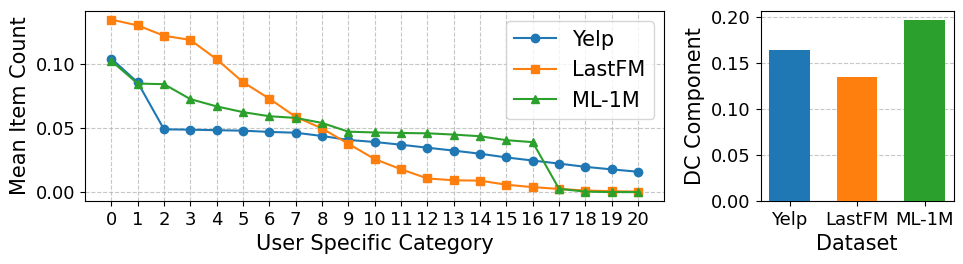

In [13]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt


def format_plots(df2):

    df2['category_counts'] = df2['categories'].apply(lambda cats: [cats.count(c) for c in cats])
    df2['item_counts'] = df2['history'].apply(lambda cats: [cats.count(c) for c in cats])
    df2['frequency'] = df2['category_counts'].apply(lambda h: [(len(h)/int(i)) /len(h) * 100 for i in h])
    df2['frequency_item'] = df2['item_counts'].apply(lambda h: [(len(h)/int(i))  /len(h) * 100 for i in h])
    df2['cat_frequency'] = df2['categories'].apply(lambda cats: {c: cats.count(c) / len(cats) for c in set(cats)})

    df2 = df2[df2['categories'].apply(lambda x: len(x) > 0)]

    df2['real_freq'] = df2['categories'].apply(lambda cats: calc_freq(cats))


    positions = defaultdict(list)
    positions_item = defaultdict(list)
    item_counts = defaultdict(list)
    category_counts = defaultdict(list)

    for index, row in df2.iterrows():
        for i, freq in enumerate(row['frequency']):
            positions[i].append(freq)
        for i, freq in enumerate(row['frequency_item']):
            positions_item[i].append(freq)
        for i, count in enumerate(row['item_counts']):
            item_counts[i].append(count)
        for i, (key, value) in enumerate(row['cat_frequency'].items()):
            category_counts[key].append(value)
            



    positions = dict(positions)
    positions_item = dict(positions_item)
    item_counts = dict(item_counts)



    results = defaultdict(list)


    for index, row in df2.iterrows():
        avg_frequencies = defaultdict(list)
        for i, (freq, clas) in enumerate(zip(row['real_freq'], row['categories'])):
            avg_frequencies[clas].append(np.abs(freq))
        
        avg_frequencies = {k: np.mean(v) for k, v in avg_frequencies.items()}

        avg_frequencies = dict(sorted(avg_frequencies.items(), key=lambda item: item[1], reverse=False))

        for i, (clas, freq) in enumerate(avg_frequencies.items()):
            results[i].append(freq)

    results = dict(results)
    results = {    k: np.mean(v) for k, v in results.items()}
    results = dict(sorted(results.items(), key=lambda item: item[1], reverse=False))
    results = {k_new + 1: v for k_new, (k_old, v) in enumerate(results.items())}

    results_df_freq = pd.DataFrame.from_dict(results, orient='index', columns=['mean_frequency'])


    cat_frequency = df2['cat_frequency']
    results_cat = defaultdict(list)

    for entry in cat_frequency:
        for i, (cat, freq) in enumerate(entry.items()):
            results_cat[i].append(np.abs(freq))

    results_cat = {k: np.sum(v) / len(cat_frequency) for k, v in results_cat.items()}
    results_cat = dict(sorted(results_cat.items(), key=lambda item: item[1], reverse=True))



    results_cat = {k_new + 1: v for k_new, (k_old, v) in enumerate(results_cat.items())}

    results_cat_df = pd.DataFrame.from_dict(results_cat, orient='index', columns=['mean_frequency'])

    # Calculate average first frequency for each dataset
    first_frequencies = []
    for index, row in df2.iterrows():
        if len(row['real_freq']) > 0:
            first_frequencies.append(np.abs(row['real_freq'][0]))
    
    avg_first_freq = np.mean(first_frequencies) if first_frequencies else 0

    return results_cat_df, results_df_freq, avg_first_freq


saved = False


if saved:
    c1 = pd.read_csv('/scratch-shared/recsys/c1_mean_frequency.csv', index_col=0)
    c2 = pd.read_csv('/scratch-shared/recsys/c2_mean_frequency.csv', index_col=0)
    c3 = pd.read_csv('/scratch-shared/recsys/c3_mean_frequency.csv', index_col=0)
    avg_first_freq_yelp = float(open('/scratch-shared/recsys/avg_first_freq_yelp.txt').read().strip())
    avg_first_freq_lastfm = float(open('/scratch-shared/recsys/avg_first_freq_lastfm.txt').read().strip())
    avg_first_freq_ml1m = float(open('/scratch-shared/recsys/avg_first_freq_ml1m.txt').read().strip())

else:
    results_df_yelp, results_df_freq_yelp, avg_first_freq_yelp = format_plots(df_yelp)
    results_df_lastfm, results_df_freq_lastfm, avg_first_freq_lastfm = format_plots(df_lastfm)
    results_df_ml1m, results_df_freq_ml1m, avg_first_freq_ml1m = format_plots(df_ml1m)


    # Top plot data
    all_idx = sorted(set(results_df_yelp.index)
                    | set(results_df_lastfm.index)
                    | set(results_df_ml1m.index))

    c1 = results_df_yelp['mean_frequency'].reindex(all_idx, fill_value=0)
    c2 = results_df_lastfm['mean_frequency'].reindex(all_idx, fill_value=0)
    c3 = results_df_ml1m['mean_frequency'].reindex(all_idx, fill_value=0)

    c1.to_csv('/scratch-shared/recsys/c1_mean_frequency.csv', index=True)
    c2.to_csv('/scratch-shared/recsys/c2_mean_frequency.csv', index=True)
    c3.to_csv('/scratch-shared/recsys/c3_mean_frequency.csv', index=True)

    with open('/scratch-shared/recsys/avg_first_freq_yelp.txt', 'w') as f:
        f.write(str(avg_first_freq_yelp))
    with open('/scratch-shared/recsys/avg_first_freq_lastfm.txt', 'w') as f:
        f.write(str(avg_first_freq_lastfm))
    with open('/scratch-shared/recsys/avg_first_freq_ml1m.txt', 'w') as f:
        f.write(str(avg_first_freq_ml1m))


top_n = 21
labels_top = [str(i) for i in range(top_n)]
x_top = np.arange(len(labels_top))
w = 0.25

# take top 30 categories from each dataset
c1 = c1[:top_n]
c2 = c2[:top_n]
c3 = c3[:top_n]

# Bottom plot data
datasets = ['Yelp','LastFM', 'ML-1M']
first_freq_values = [avg_first_freq_yelp, avg_first_freq_lastfm, avg_first_freq_ml1m]
x_bottom = np.arange(len(datasets))

fig, axs = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={'width_ratios': [3, 1]})  # Removed sharex=True

# Top plot
w = 0.3
axs[0].grid(True, linestyle='--', alpha=0.7)
line1 = axs[0].plot(x_top, c1, marker='o', label='Yelp')
line2 = axs[0].plot(x_top, c2, marker='s', label='LastFM')
line3 = axs[0].plot(x_top, c3, marker='^', label='ML-1M')
axs[0].set_xticks(x_top)
axs[0].set_xticks(x_top)
axs[0].set_xticklabels(labels_top)
axs[0].set_xlabel('User Specific Category')
axs[0].set_ylabel('Mean Item Count')
axs[0].legend(loc='upper right')

# Bottom plot

axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
bars4 = axs[1].bar(x_bottom, first_freq_values, width=0.6, 
                    color=['#1f77b4', '#ff7f0e', '#2ca02c'], zorder=3)
axs[1].set_xticks(x_bottom)
axs[1].set_xticklabels(datasets)
axs[1].set_xlabel('Dataset')
axs[1].set_ylabel('DC Component')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('mean_frequency_per_category.pdf', bbox_inches='tight')
plt.show()

In [89]:
import json
import math
import os
import glob
import re
from collections import defaultdict
import pickle

plt.rcParams.update({
    "font.size": 14,              # Base font size
    "axes.titlesize": 16,         # Axes title font
    "axes.labelsize": 15,         # Axes label font
    "xtick.labelsize": 13,        # X tick labels
    "ytick.labelsize": 13,        # Y tick labels
    "legend.fontsize": 15,        # Legend font
})

def load_files(file_pattern, print_path=False):
    files = glob.glob(file_pattern)

    seed_pattern = re.compile(r'seed_\d+\.json$')

    output = []
    for fpath in files:
        if seed_pattern.search(os.path.basename(fpath)):
            with open(fpath, 'r') as f:
                if print_path:
                    print(fpath)
                if fpath != '/scratch-shared/recsys/LastFM/BSARec_Padding_LastFM_lr_0.001_bs_256_ep_200_padding_zero_no_padding_False_seed_42.json':
                    if fpath != '/scratch-shared/recsys/LastFM/BSARec_Padding_LastFM_lr_0.001_bs_256_ep_200_padding_zero_no_padding_False_seed_42.json':
                        data = json.load(f)
                        data['filename'] = os.path.basename(fpath)
                        output.append(data)

    return output

def ndcg_k(actual, predicted, topk):
    res = 0
    for user_id in range(len(actual)):
        k = min(topk, len([actual[user_id]]))
        idcg = idcg_k(k)
        dcg_k = sum([int(predicted[user_id][j] in
                        set([actual[user_id]])) / math.log(j+2, 2) for j in range(topk)])
        res += dcg_k / idcg
    return res / float(len(actual))

# Calculates the ideal discounted cumulative gain at k
def idcg_k(k):
    res = sum([1.0/math.log(i+2, 2) for i in range(k)])
    if not res:
        return 1.0
    else:
        return res
    
def compute_ndcg_matrix(bsarec_lastfm, cutoff=10):
    num_models = len(bsarec_lastfm)
    num_items = len(bsarec_lastfm[0]['answers'])

    ndcg_bsa_lastfm = []
    for i in range(num_items):
        ndcg_row = []
        for j in range(num_models):
            answers = bsarec_lastfm[j]['answers']
            top_indices = bsarec_lastfm[j]['top_indices']
            score = ndcg_k([answers[i]], [top_indices[i]], cutoff)
            ndcg_row.append(score)
        ndcg_bsa_lastfm.append(ndcg_row)
    return ndcg_bsa_lastfm

def explode_column_with_seed(df, column_names, seed_col):
    """
    Explodes one list column independently and adds a seed column with the index of the element.
    """
    for col in  column_names:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    exploded = df.explode(column_names, ignore_index=False)
    exploded[seed_col] = exploded.groupby(level=0).cumcount()
    return exploded


def plot_ndcg_by_frequency_quartile(df_melted, dataset,
                                    models=['BSARec', 'SASRec', 'FMLPRec', 'BERT4Rec'],
                                    model_colors=None,
                                    save_path=None):
    """
    Plots mean NDCG@10 with error bars computed over seeds, grouped by frequency quartile and model.

    Parameters:
    - df_melted: pd.DataFrame with columns ['freq_quartile', 'model', 'seed', 'ndcg']
    - dataset: str, name of the dataset (used for plot title and saving filename)
    - models: list of model names (must match values in 'model' column)
    - model_colors: dict mapping model name to color hex (optional)
    - save_path: str or None, path to save the plot PDF (if None, plot won't be saved)
    """

    if model_colors is None:
        model_colors = {
            'BSARec': '#1f77b4',
            'SASRec': '#ff7f0e',
            'FMLPRec': '#2ca02c',
            'BERT4Rec': '#d62728'
        }

    # Step 1: Group by quartile, model, and seed
    grouped = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for _, row in df_melted.iterrows():
        grouped[row['freq_quartile']][row['model']][row['seed']].append(row['ndcg'])

    quartiles = sorted(grouped.keys())

    bar_width = 0.2
    x = np.arange(len(quartiles))  # base x positions for quartiles

    plt.figure(figsize=(7, 3))

    # Step 2 & 3: Compute means and stds, then plot bars with error bars
    for i, model in enumerate(models):
        ndcg_means = []
        ndcg_stds = []
        for q in quartiles:
            seed_means = []
            for seed, values in grouped[q][model].items():
                seed_means.append(np.mean(values))
            ndcg_means.append(np.mean(seed_means))
            ndcg_stds.append(np.std(seed_means))

        bar_positions = x + i * bar_width - ((len(models) - 1) / 2) * bar_width
        plt.bar(
            bar_positions,
            ndcg_means,
            yerr=ndcg_stds,
            width=bar_width,
            label=model,
            color=model_colors.get(model, None),
            capsize=4,
            zorder=3
        )

    # Step 4: Aesthetics
    plt.xlabel('Frequency Quartile')
    plt.ylabel('NDCG@10')
    plt.xticks(x, quartiles)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=len(models), frameon=False)
    plt.tight_layout()

    if save_path is None:
        save_path = f'ndcg_frequency_quartiles_{dataset}.pdf'
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def plot_ndcg_by_frequency_quartile_multiple(df_dataset_list, 
                                             models=['BSARec', 'SASRec', 'FMLPRec', 'BERT4Rec'],
                                             model_colors=None,
                                             save_path=None):
    """
    Plots mean NDCG@10 with error bars for multiple datasets side-by-side.

    Parameters:
    - df_dataset_list: list of tuples (df_melted, dataset_name)
    - models: list of model names to include
    - model_colors: optional dict of model:color
    - save_path: optional path to save the figure
    """
    if model_colors is None:
        model_colors = {
            'BSARec': '#1f77b4',
            'SASRec': '#ff7f0e',
            'FMLPRec': '#2ca02c',
            'BERT4Rec': '#d62728'
        }

    num_datasets = len(df_dataset_list)
    fixed_width_per_plot = 5  # width for each subplot
    fixed_height = 4
    bar_width = 0.2

    fig, axes = plt.subplots(1, num_datasets, figsize=(fixed_width_per_plot * num_datasets, fixed_height))

    if num_datasets == 1:
        axes = [axes]  # ensure it's iterable

    for ax, (df_melted, dataset) in zip(axes, df_dataset_list):
        # Step 1: Group by quartile, model, and seed
        grouped = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
        for _, row in df_melted.iterrows():
            grouped[row['freq_quartile']][row['model']][row['seed']].append(row['ndcg'])

        quartiles = sorted(grouped.keys())
        x = np.arange(len(quartiles))  # base x positions for quartiles

        # Step 2 & 3: Compute means and stds, then plot bars with error bars
        for i, model in enumerate(models):
            ndcg_means = []
            ndcg_stds = []
            for q in quartiles:
                seed_means = []
                for seed, values in grouped[q][model].items():
                    seed_means.append(np.mean(values))
                ndcg_means.append(np.mean(seed_means))
                ndcg_stds.append(np.std(seed_means))

            bar_positions = x + i * bar_width - ((len(models) - 1) / 2) * bar_width
            ax.bar(
                bar_positions,
                ndcg_means,
                yerr=ndcg_stds,
                width=bar_width,
                label=model,
                color=model_colors.get(model, None),
                capsize=4,
                zorder=3
            )

        # Step 4: Aesthetics per subplot
        ax.set_title(dataset)
        ax.set_xlabel('Frequency Quartile')
        ax.set_xticks(x)
        ax.set_xticklabels(quartiles)
        ax.set_ylabel('NDCG@10')
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

    # Add one global legend below the plots
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=len(models), frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)  # leave space for legend

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()


def plot_ndcg_by_quartile_of_last_multiple(df_dataset_list,
                                           models=['BSARec', 'SASRec', 'FMLPRec', 'BERT4Rec'],
                                           model_colors=None,
                                           save_path=None):
    if model_colors is None:
        model_colors = {
            'BSARec': '#1f77b4',
            'SASRec': '#ff7f0e',
            'FMLPRec': '#2ca02c',
            'BERT4Rec': '#d62728'
        }

    num_datasets = len(df_dataset_list)
    fixed_width_per_plot = 5  # width for each subplot
    fixed_height = 4
    bar_width = 0.2

    fig, axes = plt.subplots(1, num_datasets, figsize=(fixed_width_per_plot * num_datasets, fixed_height))

    if num_datasets == 1:
        axes = [axes]  # ensure it's iterable

    for ax, (df_melted, dataset) in zip(axes, df_dataset_list):
        # Step 1: Group by quartile, model, and seed
        grouped = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
        for _, row in df_melted.iterrows():
            grouped[row['quartile_of_last']][row['model']][row['seed']].append(row['ndcg'])

        quartiles = sorted(grouped.keys())
        x = np.arange(len(quartiles))  # base x positions for quartiles

        # Step 2 & 3: Compute means and stds, then plot bars with error bars
        for i, model in enumerate(models):
            ndcg_means = []
            ndcg_stds = []
            for q in quartiles:
                seed_means = []
                for seed, values in grouped[q][model].items():
                    seed_means.append(np.mean(values))
                ndcg_means.append(np.mean(seed_means))
                ndcg_stds.append(np.std(seed_means))

            bar_positions = x + i * bar_width - ((len(models) - 1) / 2) * bar_width
            ax.bar(
                bar_positions,
                ndcg_means,
                yerr=ndcg_stds,
                width=bar_width,
                label=model,
                color=model_colors.get(model, None),
                capsize=4,
                zorder=3
            )

        # Step 4: Aesthetics per subplot
        ax.set_title(dataset)
        ax.set_xlabel('Frequency Quartile')
        ax.set_xticks(x)
        ax.set_xticklabels(quartiles)
        ax.set_ylabel('NDCG@10')
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

    # Add one global legend below the plots
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=len(models), frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)  # leave space for legend

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()

    

def plot_first_frequencies_multiple(data_list, save_path=None):
    """
    Plots DC Component vs History Length for multiple datasets side-by-side.

    Parameters:
    - data_list: list of tuples (history_lengths, first_frequencies, dataset_name)
    - save_path: optional path to save the final figure
    """
    num_datasets = len(data_list)
    fixed_width_per_plot = 5
    fixed_height = 3

    fig, axes = plt.subplots(1, num_datasets, figsize=(fixed_width_per_plot * num_datasets, fixed_height))

    if num_datasets == 1:
        axes = [axes]  # ensure iterable if only one plot

    for ax, (history_lengths, first_frequencies, dataset_name) in zip(axes, data_list):
        ax.scatter(history_lengths, first_frequencies, alpha=0.5, zorder=2)
        ax.set_title(dataset_name)
        ax.set_xlabel('History Length')
        ax.set_ylabel('DC Component')
        ax.grid(True, linestyle='--', alpha=0.5, zorder=0)


    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()



Loaded existing dataframe for Yelp
Pearson correlation coefficient (r): 0.5890
P-value: 0.0000e+00
Loaded existing melted dataframe for Yelp
Loaded existing dataframe for LastFM
Pearson correlation coefficient (r): 0.4849
P-value: 2.3719e-65
Loaded existing melted dataframe for LastFM
Loaded existing dataframe for ML-1M
Pearson correlation coefficient (r): 0.3205
P-value: 2.6876e-144
Loaded existing melted dataframe for ML-1M


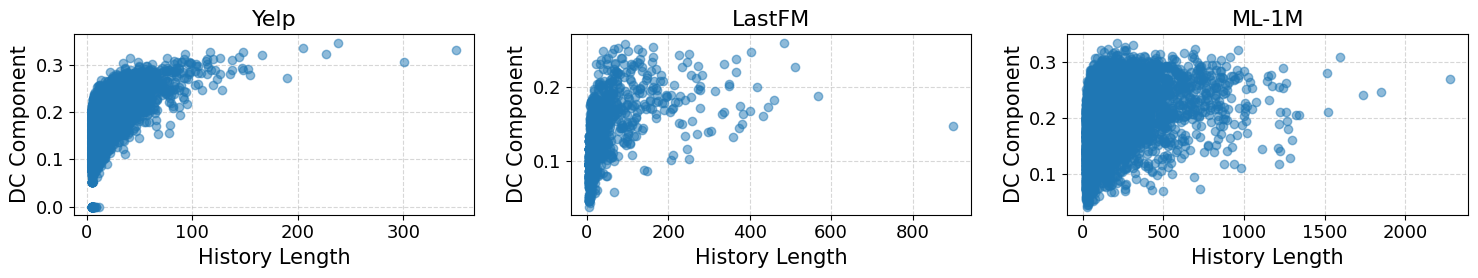

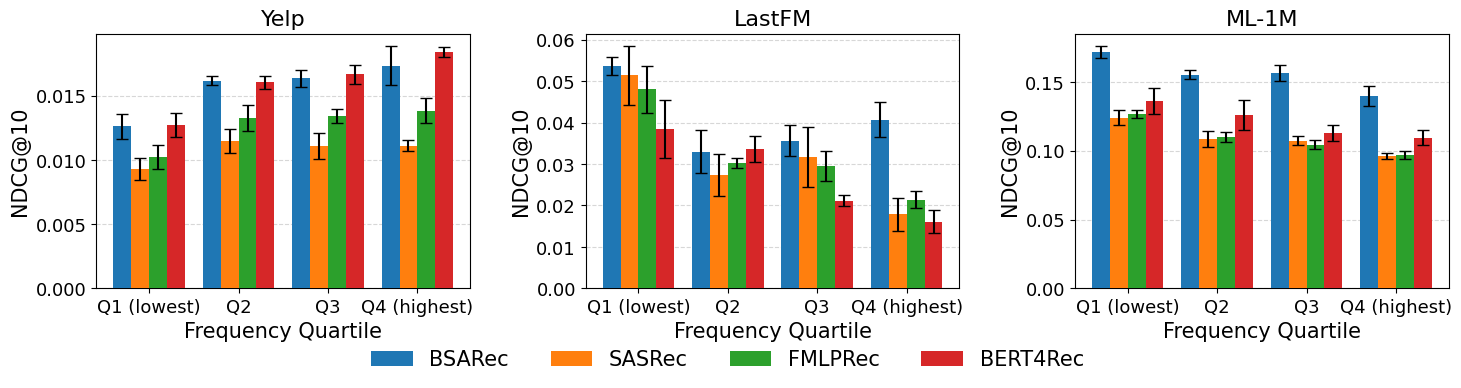

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


datasets = ['Yelp', 'LastFM', 'ML-1M']
datasets_melted_list = []
datasets_list = []
dataset_data = defaultdict(dict)

for dataset in datasets:
    file_pattern_sasrec = f'/scratch-shared/recsys/{dataset}/SASRec_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'
    file_pattern_fmlprec = f'/scratch-shared/recsys/{dataset}/FMLPRec_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'
    if dataset == 'LastFM':
        file_pattern_bsarec = f'/scratch-shared/recsys/{dataset}/BSARec_Padding_{dataset}_lr_0.001_bs_256_ep_200_padding_zero_no_padding_False_seed_*.json'
        file_pattern_bert = f'/scratch-shared/recsys/{dataset}/BERT4REC_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'
    elif dataset == 'ML-1M':
        file_pattern_bsarec = f'/scratch-shared/recsys/{dataset}/BSARec_Padding_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'
        file_pattern_bert = f'/scratch-shared/recsys/{dataset}/BERT4REC_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'
    elif dataset == 'Yelp':                                                 
        file_pattern_bsarec = f'/scratch-shared/recsys/{dataset}/BSARec_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'
        file_pattern_bert = f'/scratch-shared/recsys/{dataset}/BERT4REC_{dataset}_lr_0.0005_bs_256_ep_200_padding_zero_sequence_length_50_seed_*.json'

    if dataset == 'LastFM':
        dataframe = df_lastfm
    elif dataset == 'ML-1M':
        dataframe = df_ml1m
    elif dataset == 'Yelp':
        dataframe = df_yelp

    load_possible = True

    if os.path.exists(f'/scratch-shared/recsys/{dataset}_ndcg_frequencies.csv') and load_possible:
        dataframe = pd.read_csv(f'/scratch-shared/recsys/{dataset}_ndcg_frequencies.csv')
        print(f"Loaded existing dataframe for {dataset}")
        history_lengths = dataframe['history_length']
        first_frequencies = dataframe['first_frequency']

    else:
        bert_lastfm = load_files(file_pattern_bert, True)
        bsarec_lastfm = load_files(file_pattern_bsarec, True)
        sasrec_lastfm = load_files(file_pattern_sasrec, True)
        fmlprec_lastfm = load_files(file_pattern_fmlprec, True)

        # Calculate NDCG@10 for BSARec on LastFM
        ndcg_bsa_lastfm = compute_ndcg_matrix(bsarec_lastfm, cutoff=10)
        ndcg_sasrec_lastfm = compute_ndcg_matrix(sasrec_lastfm, cutoff=10)
        ndcg_fmlprec_lastfm = compute_ndcg_matrix(fmlprec_lastfm, cutoff=10)
        ndcg_bert_lastfm = compute_ndcg_matrix(bert_lastfm, cutoff=10)

        dataframe['real_freq'] = dataframe['categories'].apply(lambda cats: calc_freq(cats))
        dataframe['real_freq'] = dataframe['real_freq'].apply(lambda x: np.abs(x))
        dataframe['bsarec'] = ndcg_bsa_lastfm
        dataframe['sasrec'] = ndcg_sasrec_lastfm
        dataframe['fmlprec'] = ndcg_fmlprec_lastfm
        dataframe['answer'] = bsarec_lastfm[0]['answers']
        dataframe['bert'] = ndcg_bert_lastfm

        history_lengths = dataframe['history'].apply(lambda x: len(x))
        first_frequencies = dataframe['real_freq'].apply(lambda x: np.abs(x[0]) if len(x) > 0 else 0)

        # write the history lengths and first frequencies to the dataframe
        dataframe['history_length'] = history_lengths
        dataframe['first_frequency'] = first_frequencies

        # save the dataframe to scratch-shared
        dataframe.to_csv(f'/scratch-shared/recsys/{dataset}_ndcg_frequencies.csv', index=False)



    # Compute Pearson correlation
    r_value, p_value = pearsonr(first_frequencies, history_lengths)

    print(f"Pearson correlation coefficient (r): {r_value:.4f}")
    print(f"P-value: {p_value:.4e}")
    datasets_list.append(dataframe)

    if os.path.exists(f'/scratch-shared/recsys/{dataset}_melted_ndcg_frequencies.csv') and load_possible:
        df_melted = pd.read_csv(f'/scratch-shared/recsys/{dataset}_melted_ndcg_frequencies.csv')
        print(f"Loaded existing melted dataframe for {dataset}")
        
    else:
        dataframe = dataframe[dataframe['real_freq'].apply(lambda x: len(x) > 0)]
        dataframe['last_freq'] = dataframe['real_freq'].apply(lambda x: x[0] if len(x) > 0 else None)
        dataframe['freq_quartile'] = pd.qcut(dataframe['last_freq'], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

        dataframe = explode_column_with_seed(dataframe, ['bsarec', 'sasrec', 'fmlprec', 'bert'], 'seed')

        # rename columns for clarity
        dataframe.rename(columns={
            'bsarec': 'BSARec',
            'sasrec': 'SASRec',
            'fmlprec': 'FMLPRec',
            'bert': 'BERT4Rec'
        }, inplace=True)

        df_melted = dataframe.melt(id_vars=['freq_quartile', 'seed'],  
                            value_vars=['BSARec', 'SASRec', 'FMLPRec', 'BERT4Rec'],
                            var_name='model', value_name='ndcg')



        # write the melted dataframe to scratch-shared
        df_melted.to_csv(f'/scratch-shared/recsys/{dataset}_melted_ndcg_frequencies.csv', index=False)

    datasets_melted_list.append(df_melted)

    dataset_data[dataset]['history_length'] = history_lengths
    dataset_data[dataset]['first_frequencies'] = first_frequencies
    dataset_data[dataset]['dataframe'] = dataframe

plot_first_frequencies_multiple([
    (datasets_list[0]['history_length'], datasets_list[0]['first_frequency'], datasets[0]),
    (datasets_list[1]['history_length'], datasets_list[1]['first_frequency'], datasets[1]),
    (datasets_list[2]['history_length'], datasets_list[2]['first_frequency'], datasets[2])
], save_path='dc_component_vs_history_length.png'
)   

plot_ndcg_by_frequency_quartile_multiple(df_dataset_list=[
    (datasets_melted_list[0], datasets[0]),
    (datasets_melted_list[1], datasets[1]),
    (datasets_melted_list[2], datasets[2])
], save_path='combined_ndcg_plot.pdf'
)

In [77]:
df = explode_column_with_seed(df, ['bsarec', 'sasrec', 'fmlprec', 'bert'], 'seed')

Dataset: Yelp - quartile counts:
quartile_of_last
Q1      16739
Q2       5534
Q3       5973
Q4       2145
none        0

Dataset: LastFM - quartile counts:
quartile_of_last
Q1      452
Q2      202
Q3      337
Q4       92
none      0

Dataset: ML-1M - quartile counts:
quartile_of_last
Q1      3719
Q2      1049
Q3       791
Q4       475
none       0



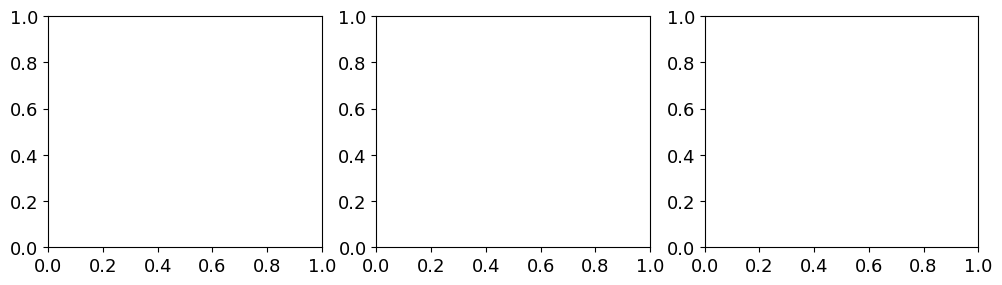

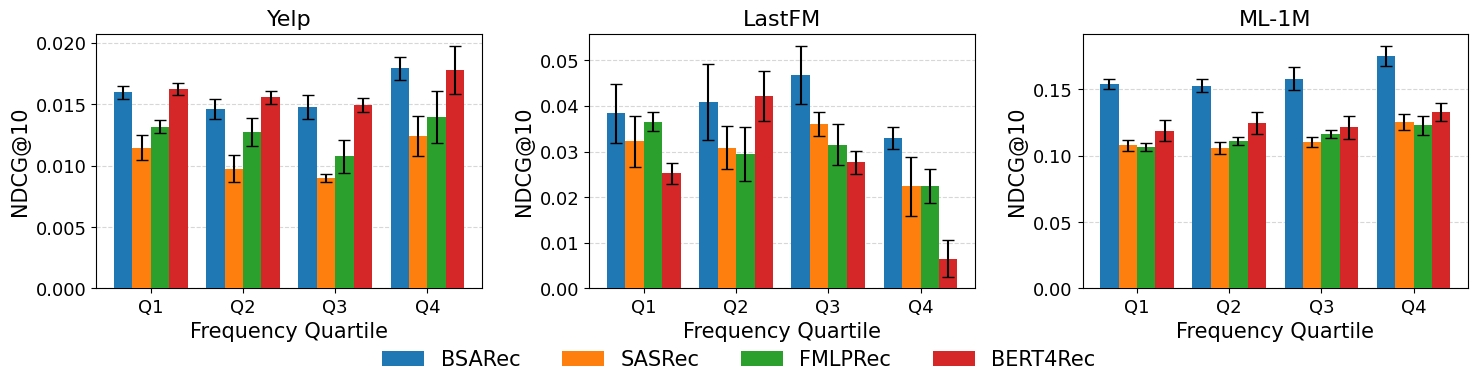

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import math
import ast
datasets_melted_list = []
# List of datasets to plot
datasets = ['Yelp', 'LastFM', 'ML-1M']


for idx, dataset in enumerate(datasets):
    df = dataset_data[dataset]['dataframe'].copy()

    # Compute quartile_of_last for each user history
    quartiles = []
    for history in df['category_counts']:
        freq_counts = Counter((ast.literal_eval(history)[:-1]))
        sorted_items = [val for val, _ in freq_counts.most_common()]
        n = len(sorted_items)
        rank_map = {val: i for i, val in enumerate(sorted_items)}
        if len(ast.literal_eval(history)) != 0:
            last_val = ast.literal_eval(history)[-1]
            if last_val not in rank_map:
                quartiles.append('none')
            else:
                rank = rank_map[last_val]
                q = min(math.floor((rank / n) * 4) + 1, 4)
                quartiles.append(f'Q{q}')
        else:
            quartiles.append('none')

    df['quartile_of_last'] = quartiles

    # drop all entries with quartile of last == none
    df = df[df['quartile_of_last'] != 'none']

    # Print counts per quartile and 'none'
    count_series = df['quartile_of_last'].value_counts().reindex(['Q1', 'Q2', 'Q3', 'Q4', 'none'], fill_value=0)
    print(f"Dataset: {dataset} - quartile counts:")
    print(count_series.to_string())
    print()  # blank line for readability

    df = explode_column_with_seed(df, ['bsarec', 'sasrec', 'fmlprec', 'bert'], 'seed')

    df.rename(columns={
    'bsarec': 'BSARec',
    'sasrec': 'SASRec',
    'fmlprec': 'FMLPRec',
    'bert': 'BERT4Rec'
}, inplace=True)
    
    df_melted = df.melt(id_vars=['quartile_of_last', 'seed'],  
                                value_vars=['BSARec', 'SASRec', 'FMLPRec', 'BERT4Rec'],
                                var_name='model', value_name='ndcg')


    datasets_melted_list.append(df_melted)


plot_ndcg_by_quartile_of_last_multiple(df_dataset_list=[
    (datasets_melted_list[0], datasets[0]),
    (datasets_melted_list[1], datasets[1]),
    (datasets_melted_list[2], datasets[2])
], save_path='combined_ndcg_last_item_plot.pdf'
)

In [94]:
datasets_melted_list[0]

,user_id,history,categories,unique_categories,real_freq,BSARec,SASRec,FMLPRec,answer,BERT4Rec,history_length,first_frequency,category_counts,item_counts,frequency,frequency_item,cat_frequency,quartile_of_last,seed
0,1,"['1', '2', '3', '4', '3', '5', '6', '3', '7', ...","[19, 2, 24, 27, 7, 23, 120, 8, 9, 18, 62, 40, ...","[2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 18, ...",[0.28907181 0.91832236 0.94501369 0.95022235 0...,0.0,0.0,0.0,56,0.0,69,0.289072,"[2, 62, 7, 17, 5, 14, 4, 18, 18, 10, 4, 2, 14,...","[1, 3, 4, 2, 4, 1, 1, 4, 1, 2, 1, 1, 1, 3, 5, ...","[50.0, 1.6129032258064515, 14.285714285714285,...","[100.0, 33.33333333333333, 25.0, 50.0, 25.0, 1...","{2: 0.18128654970760233, 4: 0.0029239766081871...",Q2,0
0,1,"['1', '2', '3', '4', '3', '5', '6', '3', '7', ...","[19, 2, 24, 27, 7, 23, 120, 8, 9, 18, 62, 40, ...","[2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 18, ...",[0.28907181 0.91832236 0.94501369 0.95022235 0...,0.0,0.0,0.0,56,0.0,69,0.289072,"[2, 62, 7, 17, 5, 14, 4, 18, 18, 10, 4, 2, 14,...","[1, 3, 4, 2, 4, 1, 1, 4, 1, 2, 1, 1, 1, 3, 5, ...","[50.0, 1.6129032258064515, 14.285714285714285,...","[100.0, 33.33333333333333, 25.0, 50.0, 25.0, 1...","{2: 0.18128654970760233, 4: 0.0029239766081871...",Q2,1
0,1,"['1', '2', '3', '4', '3', '5', '6', '3', '7', ...","[19, 2, 24, 27, 7, 23, 120, 8, 9, 18, 62, 40, ...","[2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 18, ...",[0.28907181 0.91832236 0.94501369 0.95022235 0...,0.0,0.0,0.0,56,0.0,69,0.289072,"[2, 62, 7, 17, 5, 14, 4, 18, 18, 10, 4, 2, 14,...","[1, 3, 4, 2, 4, 1, 1, 4, 1, 2, 1, 1, 1, 3, 5, ...","[50.0, 1.6129032258064515, 14.285714285714285,...","[100.0, 33.33333333333333, 25.0, 50.0, 25.0, 1...","{2: 0.18128654970760233, 4: 0.0029239766081871...",Q2,2
0,1,"['1', '2', '3', '4', '3', '5', '6', '3', '7', ...","[19, 2, 24, 27, 7, 23, 120, 8, 9, 18, 62, 40, ...","[2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 18, ...",[0.28907181 0.91832236 0.94501369 0.95022235 0...,0.0,0.0,0.0,56,0.0,69,0.289072,"[2, 62, 7, 17, 5, 14, 4, 18, 18, 10, 4, 2, 14,...","[1, 3, 4, 2, 4, 1, 1, 4, 1, 2, 1, 1, 1, 3, 5, ...","[50.0, 1.6129032258064515, 14.285714285714285,...","[100.0, 33.33333333333333, 25.0, 50.0, 25.0, 1...","{2: 0.18128654970760233, 4: 0.0029239766081871...",Q2,3
0,1,"['1', '2', '3', '4', '3', '5', '6', '3', '7', ...","[19, 2, 24, 27, 7, 23, 120, 8, 9, 18, 62, 40, ...","[2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 18, ...",[0.28907181 0.91832236 0.94501369 0.95022235 0...,0.0,0.0,0.0,56,0.0,69,0.289072,"[2, 62, 7, 17, 5, 14, 4, 18, 18, 10, 4, 2, 14,...","[1, 3, 4, 2, 4, 1, 1, 4, 1, 2, 1, 1, 1, 3, 5, ...","[50.0, 1.6129032258064515, 14.285714285714285,...","[100.0, 33.33333333333333, 25.0, 50.0, 25.0, 1...","{2: 0.18128654970760233, 4: 0.0029239766081871...",Q2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30429,30430,"['11197', '11197', '11197', '11197', '11197', ...","[32, 33, 60, 359, 112, 18, 19, 32, 33, 60, 359...","[32, 33, 359, 112, 18, 19, 60]",[0.10557282 1. 1. 1. 1...,0.0,0.0,0.0,11197,0.0,6,0.105573,"[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...","[6, 6, 6, 6, 6, 6]","[16.666666666666664, 16.666666666666664, 16.66...","[16.666666666666664, 16.666666666666664, 16.66...","{32: 0.14285714285714285, 33: 0.14285714285714...",Q1,0
30429,30430,"['11197', '11197', '11197', '11197', '11197', ...","[32, 33, 60, 359, 112, 18, 19, 32, 33, 60, 359...","[32, 33, 359, 112, 18, 19, 60]",[0.10557282 1. 1. 1. 1...,0.0,0.0,0.0,11197,0.0,6,0.105573,"[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...","[6, 6, 6, 6, 6, 6]","[16.666666666666664, 16.666666666666664, 16.66...","[16.666666666666664, 16.666666666666664, 16.66...","{32: 0.14285714285714285, 33: 0.14285714285714...",Q1,1
30429,30430,"['11197', '11197', '11197', '11197', '11197', ...","[32, 33, 60, 359, 112, 18, 19, 32, 33, 60, 359...","[32, 33, 359, 112, 18, 19, 60]",[0.10557282 1. 1. 1. 1...,0.0,0.0,0.0,11197,0.0,6,0.105573,"[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...","[6, 6, 6, 6, 6, 6]","[16.666666